# Contrast Synthesis - load, run, and visualize

Loads the trained contrast-synthesis U-Net (`Unet2D`) from a config + checkpoint,
runs it on the BraTS validation split, and shows **inputs | ground-truth T1ce | prediction | error**.

Uses ImMAP's own APIs (`build_model`, `build_loader`, `load_ckpt`, `compute_metrics`), so it
stays in sync with training. Run from the ImMAP repo in the ImMAP environment (torch 2.x + matplotlib).
The first cell moves the working directory to the repo root.

In [1]:
import os, sys, json
import numpy as np
import torch
import matplotlib.pyplot as plt

# This notebook lives in ImMAP/notebooks/. Move to the repo root so that
# `models`/`datasets`/`training` import and the relative config/ckpt paths resolve.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
REPO_ROOT = os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
print("Repo root:", REPO_ROOT)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Repo root: /scratch/ee2178/ImMAP
Device: cuda


## 1. Config + checkpoint

Point `CONFIG_PATH` at the run you want to inspect. The checkpoint is taken from `paths.ckpt`
if set, otherwise from `<save_dir>/net.ckpt` (what the training loop writes).

In [52]:
from models import build_model
from datasets import build_loader
from training.common import load_ckpt, apply_loss_mask
from training.metrics import compute_metrics

CONFIG_PATH = "config/BraTS/synthesis.json"            # warm-started (CCL) run
# CONFIG_PATH = "config/BraTS/synthesis_nopretrain.json"  # from-scratch baseline

with open(CONFIG_PATH) as f:
    cfg = json.load(f)

ckpt_path = cfg["paths"].get("ckpt") or os.path.join(cfg["paths"]["save_dir"], "net.ckpt")
print("Task:", cfg["task"], "| model:", cfg["model"]["type"])
print("Checkpoint:", ckpt_path, "| exists:", os.path.exists(ckpt_path))

Task: synthesis | model: Unet2D
Checkpoint: trained_nets/brats/Synth_T1ce_Pretrain_VGG_CosLR/net.ckpt | exists: True


## 2. Build the network and load weights

In [53]:
net = build_model(cfg).to(device)

if os.path.exists(ckpt_path):
    net, _, _, step = load_ckpt(ckpt_path, model=net, device=device)
    print(f"Loaded checkpoint (step {step}).")
else:
    print("[warn] checkpoint not found -- using RANDOM weights (plumbing/demo only).")

net.eval()
print(f"{cfg['model']['type']}: {sum(p.numel() for p in net.parameters())/1e6:.2f}M params")

Loading model state dict...
Loaded checkpoint (step 505751).
Unet2D: 2.31M params


## 3. Load + prep a validation batch

`build_loader` wraps `SynthesisDataset` (which reads the per-subject `*_img.h5`, z-scored within
brain, background = 0). Each item is `X:(Cin,H,W)`, `y:(1,H,W)` (T1ce), `mask:(1,H,W)` brain mask.
Validation uses no shuffle / no augmentation; 0 workers is friendliest inside a notebook.

In [5]:
val_cfg = dict(cfg["data"]["val"])
val_cfg["num_workers"] = 0
loader = build_loader(val_cfg, shuffle=True, drop_last=False)
print("Validation slices:", len(loader.dataset))

X, y, mask = next(iter(loader))     # X:(B,Cin,H,W)  y:(B,1,H,W)  mask:(B,1,H,W)
print("X", tuple(X.shape), "| y", tuple(y.shape), "| mask", tuple(mask.shape))

Validation slices: 17548
X (8, 3, 240, 240) | y (8, 1, 240, 240) | mask (8, 1, 240, 240)


## 4. Run inference + score (same masking/metrics as the training loop)

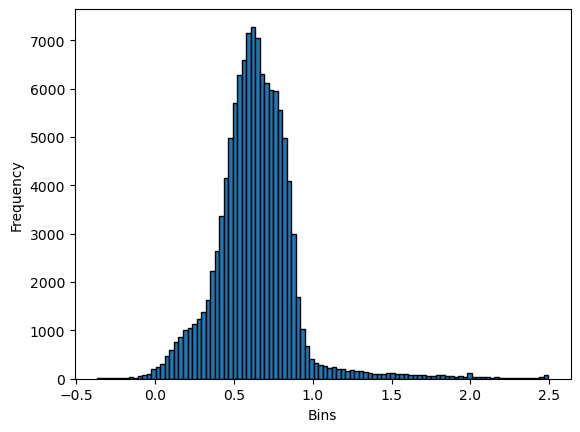

In [48]:
# Compute histogram using PyTorch
counts, edges = torch.histogram(((y_m[mask.bool()]+2.5)/4).detach().cpu(), bins=100)

# Plot using matplotlib bar chart
plt.bar(edges[:-1], counts, width=torch.diff(edges), align='edge', edgecolor='black')
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.show()

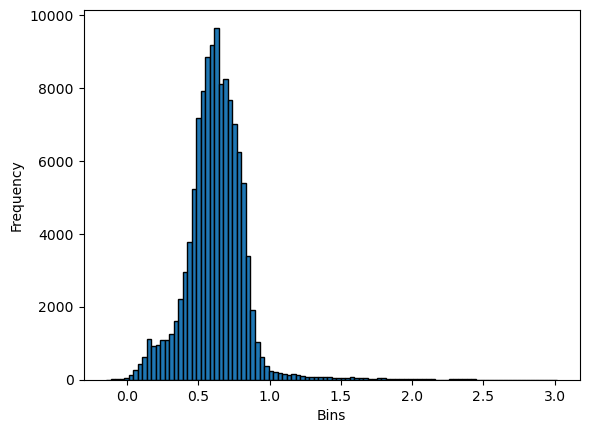

In [49]:
# Compute histogram using PyTorch
counts, edges = torch.histogram(((pred_m[mask.bool()]+2.5)/4).detach().cpu(), bins=100)

# Plot using matplotlib bar chart
plt.bar(edges[:-1], counts, width=torch.diff(edges), align='edge', edgecolor='black')
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.show()

In [54]:
# Stored channel order (cmap.yaml): [flair, t1, t1ce, t2]
CONTRASTS  = ["FLAIR", "T1", "T1ce", "T2"]
input_idx  = list(cfg["data"]["val"]["input_idx"])
target_idx = list(cfg["data"]["val"]["target_idx"])
in_names   = [CONTRASTS[i] for i in input_idx]
out_name   = CONTRASTS[target_idx[0]]
use_mask   = cfg["training"].get("use_mask", True)
print("Inputs:", in_names, "-> target:", out_name)

X, y, mask = X.to(device), y.to(device), mask.to(device)
with torch.no_grad():
    pred = net(X)                                   # (B, 1, H, W)

# apply the same brain masking the val loop uses before scoring
y_m, pred_m = apply_loss_mask(y, pred, mask, use_mask)

per_sample = []
for b in range(X.shape[0]):
    # Both are roughly -2 to 2, so we can do some rescaling to "fix" our metrics
    m = compute_metrics((y_m[b:b+1]+2.5)/4, (pred_m[b:b+1]+2.5)/4)
    per_sample.append({k: float(v) for k, v in m.items()})

print("batch mean  PSNR {:.2f} | SSIM {:.3f} | NRMSE {:.4f}".format(
    np.mean([m["psnr"]  for m in per_sample]),
    np.mean([m["ssim"]  for m in per_sample]),
    np.mean([m["nrmse"] for m in per_sample])))

Inputs: ['FLAIR', 'T1', 'T2'] -> target: T1ce
batch mean  PSNR 22.62 | SSIM 0.910 | NRMSE 0.0305


## 5. Visualize

Rows = the slices with the most brain in the batch. Columns = input contrasts, GT T1ce,
prediction, and the absolute error inside the brain. Images are z-scored, so displays use a
robust (1-99 percentile) scale; **GT and Pred share one scale** so they are directly comparable.

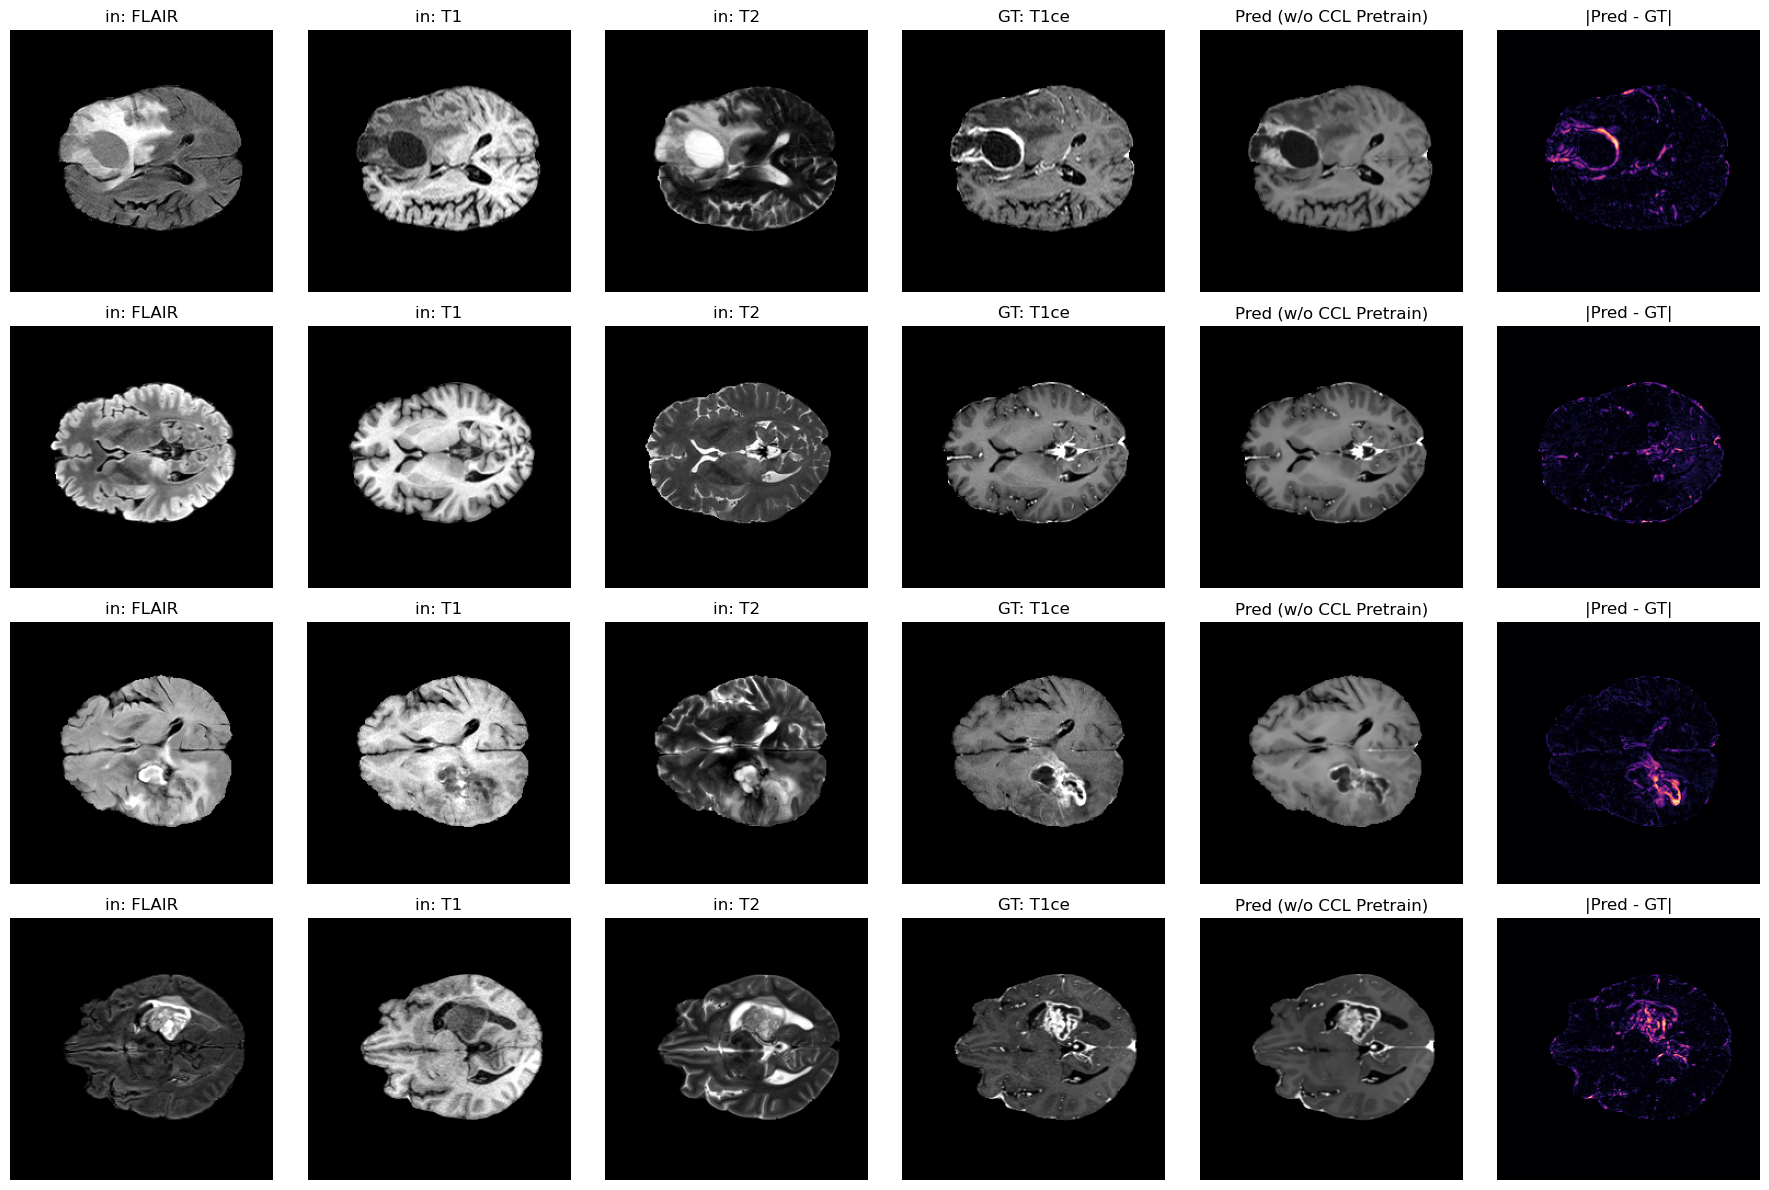

In [55]:
def robust_scale(ref, p=(1, 99)):
    lo, hi = (np.percentile(ref, p) if ref.size else (0.0, 1.0))
    return lo, (hi - lo + 1e-8)

def norm(img, lo, span):
    return np.clip((img - lo) / span, 0, 1)

# pick the fullest-brain slices (skip near-empty edge slices)
brain_frac = mask.flatten(1).float().mean(1)
sel = torch.argsort(brain_frac, descending=True)[:min(4, X.shape[0])].tolist()

ncols = len(in_names) + 3           # inputs | GT | Pred | Error
fig, axes = plt.subplots(len(sel), ncols, figsize=(3 * ncols, 3 * len(sel)))
axes = np.atleast_2d(axes)

for r, b in enumerate(sel):
    m2d = mask[b, 0].bool().cpu().numpy()

    # input contrasts: each scaled on its own foreground
    for c, name in enumerate(in_names):
        img = X[b, c].cpu().numpy()
        lo, span = robust_scale(img[m2d])
        axes[r, c].imshow(norm(img, lo, span)*mask[b, 0].detach().cpu().numpy(), cmap="gray")
        axes[r, c].set_title(f"in: {name}")

    # GT and Pred: shared scale (from GT foreground) -> visually comparable
    gt = y[b, 0].cpu().numpy()
    pr = pred[b, 0].cpu().numpy()
    lo, span = robust_scale(gt[m2d])
    axes[r, len(in_names)].imshow(norm(gt, lo, span)*mask[b, 0].detach().cpu().numpy(), cmap="gray")
    axes[r, len(in_names)].set_title(f"GT: {out_name}")
    axes[r, len(in_names) + 1].imshow(norm(pr, lo, span)*mask[b, 0].detach().cpu().numpy(), cmap="gray")
    # axes[r, len(in_names) + 1].set_title("Pred  PSNR {:.1f} / SSIM {:.3f}".format(
    #     per_sample[b]["psnr"], per_sample[b]["ssim"]))
    axes[r, len(in_names) + 1].set_title("Pred (w/o CCL Pretrain)")
    # absolute error within the brain
    err = np.abs(pr - gt) * m2d
    axes[r, len(in_names) + 2].imshow(err, cmap="magma")
    axes[r, len(in_names) + 2].set_title("|Pred - GT|")

    for c in range(ncols):
        axes[r, c].axis("off")

plt.tight_layout()
plt.show()

## Notes

- **Needs a trained checkpoint** at `<save_dir>/net.ckpt` (or set `paths.ckpt`). Without one the
  cell falls back to random weights so the plumbing still runs.
- **Whole-set metrics:** loop over `loader` accumulating `compute_metrics(y_m, pred_m)` batch-by-batch
  instead of scoring a single batch.
- Metrics here match the training/val loop exactly (brain-masked, then `compute_metrics`), so numbers
  are comparable to the W&B `val/*` logs.
- The `synthesis` val loader does not forward `crop_size`, so slices are native 240x240; and since the
  val split uses no augmentation, the brain mask stays aligned with `X`/`y`.